# Import Required Libraries

Import libraries such as `json`, `pandas`, `matplotlib.pyplot`, and `seaborn` for data manipulation and visualization.


In [1]:
import matplotlib.pyplot as plt  # For plotting
import pandas as pd  # For data manipulation
import seaborn as sns  # For enhanced visualizations

from d3bench import methods  # For benchmarking methods
import tables  # For handling pandas tables

# Configure seaborn for better aesthetics
sns.set_theme(style="whitegrid")

2025-03-31 15:26:03.268393: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-31 15:26:03.292446: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-31 15:26:03.292477: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-31 15:26:03.292495: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-31 15:26:03.297832: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-31 15:26:03.298428: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


/home/borja/miniforge3/envs/d3b/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load JSON Files

Load the JSON files from different frameworks into Python dictionaries for further processing.


In [2]:
files = {
    "Alibi-Detect": "results/results_alibidetect_20250325112836.json",
    "Evidently": "results/results_evidently_20250321143343.json",
    "Frouros": "results/results_frouros_20250325113341.json",
    "NannyML": "results/results_nannyml_20250321103604.json",
    "River": "results/results_river_20250325155340.json",
}

data = tables.load_json(files)
print("JSON files loaded successfully.")

JSON files loaded successfully.


# Extract and Normalize Data

Extract relevant data (runtime, memory, CPU time) from each JSON file and normalize it into a consistent format using Pandas DataFrames.


In [3]:
data_frames = {
    name: tables.extract(framework_data, name, methods.BatchCD) 
    for name, framework_data in data.items()
}  # fmt: skip

combined_df = pd.concat(
    [df for df in data_frames.values()],
    ignore_index=True,
)
combined_df.head()

,Framework,Method,Runtime (avg),Runtime (max),Runtime (min),CPU Time (avg),CPU Time (max),CPU Time (min),Memory (avg),Memory (max),Memory (min)
0,Alibi-Detect,Chi-square Test,0.050697,0.051836,0.049204,0.049389,0.050020,0.048363,1332.742188,1332.742188,1332.742188
1,Alibi-Detect,Kolmogorov-Smirnov Test,0.014441,0.016635,0.012953,0.012877,0.013031,0.012798,1332.875000,1332.875000,1332.875000
2,Alibi-Detect,Cramér-von Mises Test,0.015656,0.017359,0.014664,0.014812,0.014892,0.014770,1333.035156,1333.035156,1333.035156
3,Alibi-Detect,Mixed-Type Tabular Data,0.013941,0.014563,0.013545,0.013124,0.013210,0.013070,1333.046875,1333.046875,1333.046875
4,Evidently,Kolmogorov-Smirnov Test,0.121274,0.151694,0.099139,0.095469,0.096653,0.094758,513.170573,513.171875,513.167969


# Compare Metrics Across Frameworks

Bar plots to compare the metrics of methods across different frameworks.


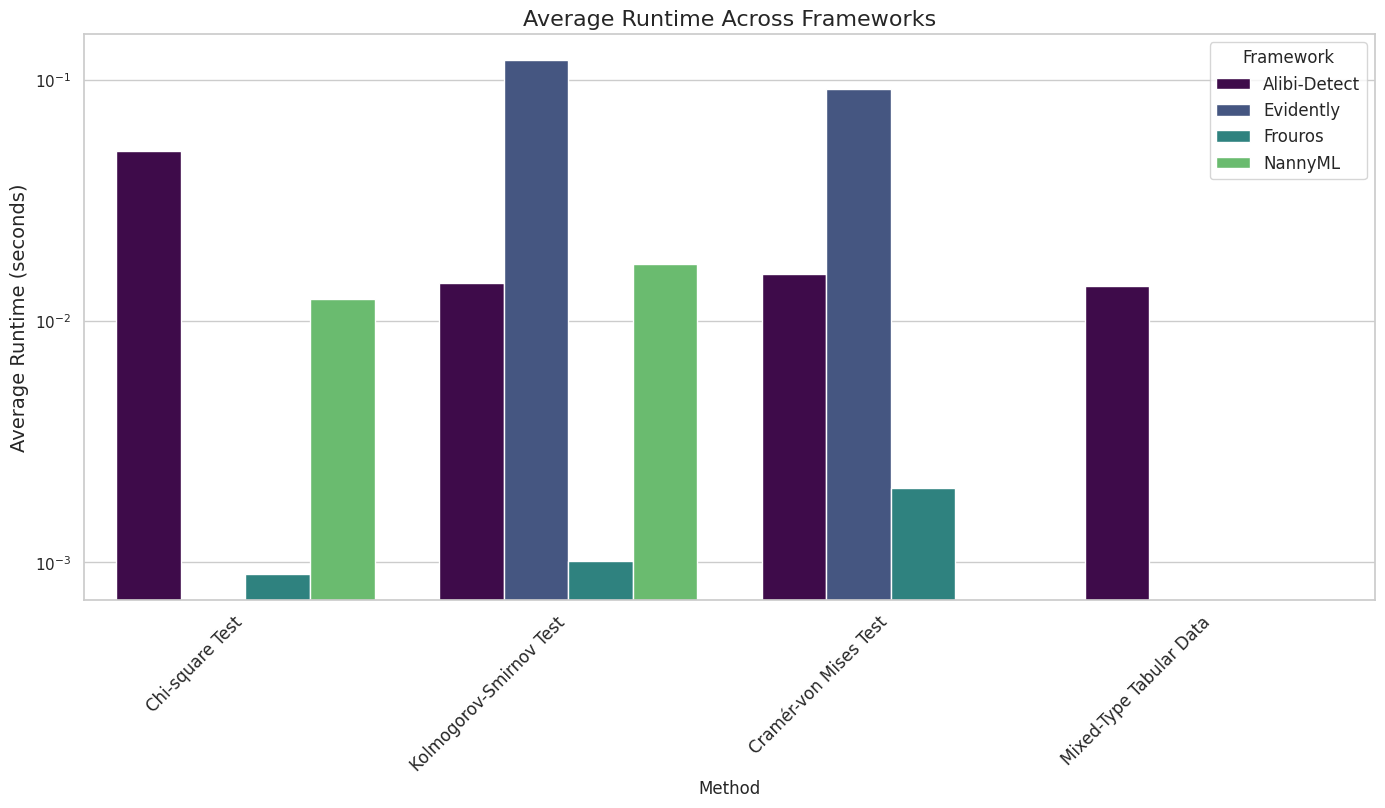

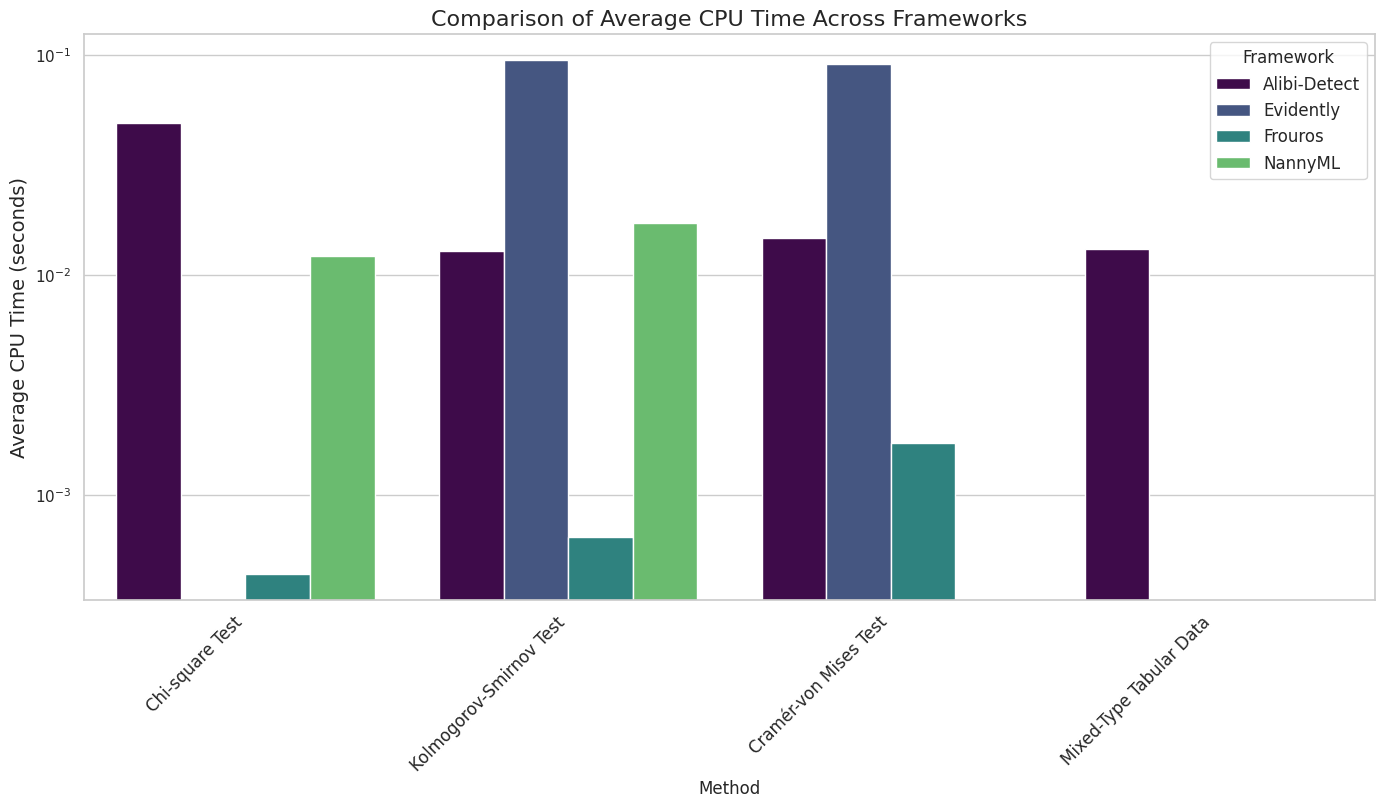

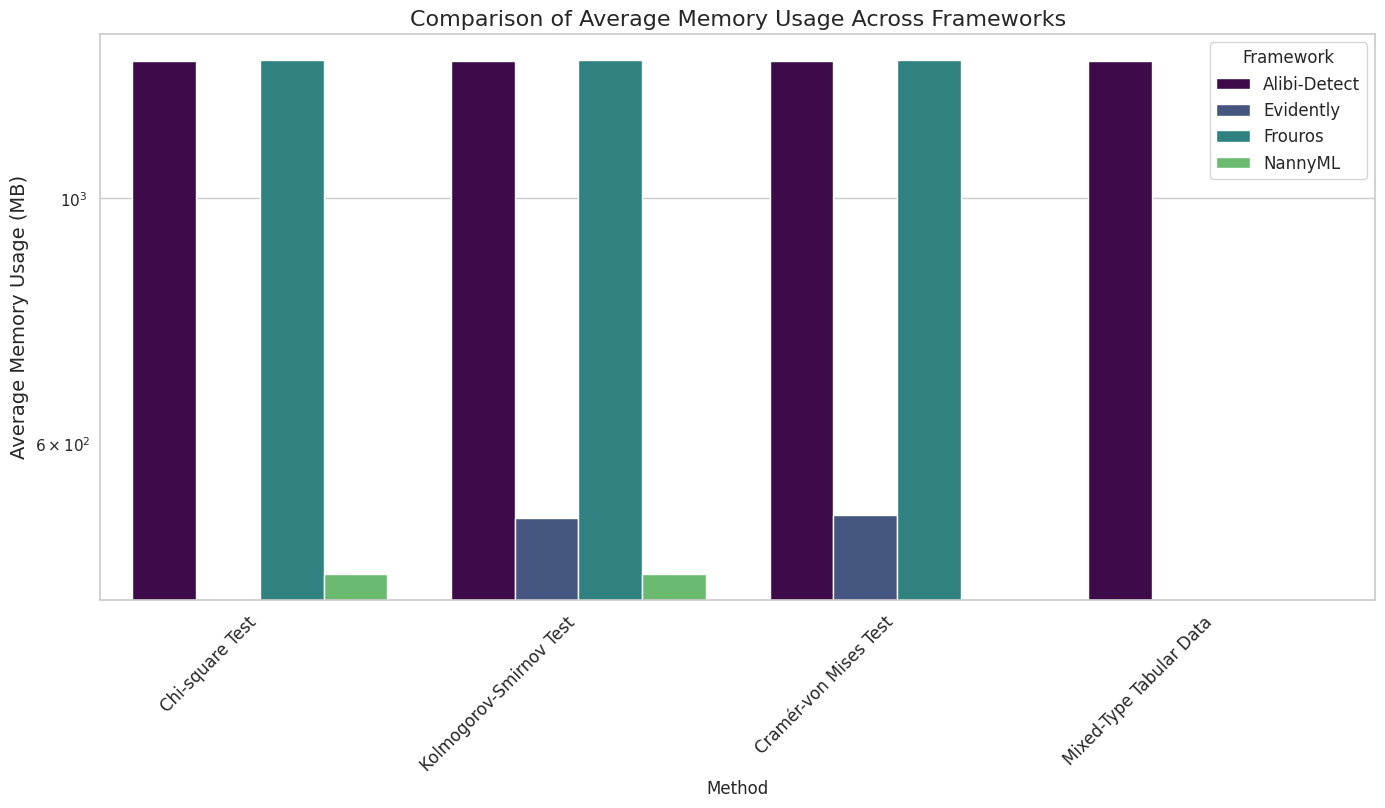

In [4]:
tables.plot(combined_df, y="Runtime")
plt.title("Average Runtime Across Frameworks", fontsize=16)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.show()

tables.plot(combined_df, y="CPU Time")
plt.title("Comparison of Average CPU Time Across Frameworks", fontsize=16)
plt.ylabel("Average CPU Time (seconds)", fontsize=14)
plt.show()

tables.plot(combined_df, y="Memory")
plt.title("Comparison of Average Memory Usage Across Frameworks", fontsize=16)
plt.ylabel("Average Memory Usage (MB)", fontsize=14)
plt.show()